# Análise Exploratória dos dados para X-Health

- Autora: Natália de Faria

## Importando bibliotecas

In [1]:
#adicionando retorno no diretório ao caminho
import sys
sys.path.append('../')

#ignorar warnings 
import warnings
warnings.filterwarnings('ignore')

In [2]:
#adicionando variáveis globais
from src.globals import *

import pandas as pd 
import numpy as np

import pytz
import time
import gc

from loguru import logger
import csv
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

2025-02-01 19:14:08.771 | INFO     | src.globals:<module>:7 - PROJ_ROOT path is C:\Users\Natalia\OneDrive\Documentos\PROJETOS\x_health


In [30]:
#mostrar todas as colunas
pd.set_option('display.max_columns',None)

### Importando base

In [ ]:
#importando a base do arquivo externo
nome_base = f'{EXTERNAL_DATA_DIR}/dataset_2021-5-26-10-14.csv'
df = pd.read_csv(nome_base, sep = '\t' ,encoding = 'utf-8')
logger.info(f'Base importada com tamanho: {len(df)}')

2025-02-01 19:36:00.506 | INFO     | __main__:<module>:4 - A base tem tamanho: 117273


In [31]:
df.head(3)

,default_3months,ioi_36months,ioi_3months,valor_por_vencer,valor_vencido,valor_quitado,quant_protestos,valor_protestos,quant_acao_judicial,acao_judicial_valor,participacao_falencia_valor,dividas_vencidas_valor,dividas_vencidas_qtd,falencia_concordata_qtd,tipo_sociedade,opcao_tributaria,atividade_principal,forma_pagamento,valor_total_pedido,month,year,default
0,0,58.000000,18.236092,0.00,0.0,242100.70,0,0.0,0,0.0,0.0,0.0,0,0,empresario (individual),simples nacional,papelaria,30/60/90,34665.674938,6,2019,0
1,1,16.052632,7.500000,224132.85,0.0,4960846.21,0,0.0,0,0.0,0.0,0.0,0,0,sociedade empresaria limitada,<NA>,com de equipamentos de informatica,30/60/90,7134.489373,10,2018,0
2,0,13.250000,3.904762,513043.83,0.0,158631.93,1,1800.0,0,0.0,0.0,0.0,0,0,sociedade empresaria limitada,simples nacional,servicos de vigilancia e guarda,<NA>,72653.621143,4,2018,0


## Setando variáveis e calculando taxas de evento e não evento

In [42]:
#setando variáveis de interesse
inadimplencia = 'default'

# taxa de inadimpência na base
taxa_inadimplencia = df[inadimplencia].mean()
evento = df[inadimplencia].sum()
nao_evento = len(df) - evento

logger.info(f'Avaliando conceito de inadimplencia na base:')
print(f'Na base temos {evento} casos de inadimplência e {nao_evento} de não eventos')
print(f'Esses valores geram uma taxa base de inadimplência de {taxa_inadimplencia}')
print(f'Então, um evento é uma inadimplência a cada {round(1/taxa_inadimplencia)} analisados, aproximadamente')

2025-02-01 19:44:20.900 | INFO     | __main__:<module>:9 - Avaliando conceito de inadimplencia na base:


Na base temos 19545 casos de inadimplência e 97728 de não eventos
Esses valores geram uma taxa base de inadimplência de 0.16666240311069044
Então, um evento é uma inadimplência a cada 6 analisados, aproximadamente


In [46]:
print('Media de inadimplência nos anos: ')
df.groupby('year')[inadimplencia].mean()

Media de inadimplência nos anos: 


year
2017    0.133478
2018    0.189044
2019    0.164740
Name: default, dtype: float64

In [6]:
# Definir colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(exclude=['number']).columns.tolist()

## Análise de missings na base

In [7]:
# Substituindo "missing" por NaN
df.replace("missing", pd.NA, inplace=True)

In [8]:
# Valores ausentes
total_missing = df.isna().sum()
percentual_missing = (total_missing / len(df)) * 100

In [9]:
# DF com os resultados
missing_df = pd.DataFrame({
    'Coluna': df.columns,
    'Valores Faltantes': percentual_missing.values,
    'Percentual (%)': percentual_missing.values
})

In [10]:
# Filtrar ausentes
missing_df = missing_df[missing_df["Valores Faltantes"] > 0]

In [11]:
# Exibir os resultados
print(missing_df.sort_values(by="Percentual (%)", ascending=False))

                 Coluna  Valores Faltantes  Percentual (%)
17      forma_pagamento          27.693501       27.693501
15     opcao_tributaria          15.625933       15.625933
14       tipo_sociedade           0.518448        0.518448
16  atividade_principal           0.504805        0.504805


- alto valor de missing em forma_pagamento, possíveis causas:
    - erro de preenchimento
    - clientes novos sem histórico
    - erro na coleta (ex: campo não obrigatório)
- To do:
    - analisar impacto na correlação com inadimplência

- alta taxa de missings em opção_tribuitaria, possíveis causas:
    - Falta de imformação na compra
    - problema de integração
- to do:
    - avaliar o comportamento de risco de quem tem missings
    - preencher com valores baseados nos dados (?)

## Análise de Outliers

### Z-Score

In [12]:
# Calcular o Z-Score
z_scores = np.abs(stats.zscore(df[numeric_cols]))

# Identificar outliers (Z > 3)
outliers_z = (z_scores > 3)

# Contar quantos outliers existem por coluna e transformar em Series
outliers_z_count = pd.Series(outliers_z.sum(axis=0), index=numeric_cols)

# Ordenar os resultados
print(outliers_z_count[outliers_z_count > 0].sort_values(ascending=False))

ioi_3months                2649
ioi_36months               2169
default_3months            1533
valor_quitado               974
valor_por_vencer            762
quant_acao_judicial         413
dividas_vencidas_qtd        235
valor_vencido               188
valor_total_pedido          171
valor_protestos             112
quant_protestos              69
acao_judicial_valor          58
falencia_concordata_qtd      54
dividas_vencidas_valor       11
dtype: int64


In [13]:
print(outliers_z_count[outliers_z_count > 0])

default_3months            1533
ioi_36months               2169
ioi_3months                2649
valor_por_vencer            762
valor_vencido               188
valor_quitado               974
quant_protestos              69
valor_protestos             112
quant_acao_judicial         413
acao_judicial_valor          58
dividas_vencidas_valor       11
dividas_vencidas_qtd        235
falencia_concordata_qtd      54
valor_total_pedido          171
dtype: int64


### Regra do Intervalo Interquartil (IQR) > 1.5

In [26]:
# Calcular Q1, Q3 e IQR para cada coluna numérica
numeric_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Determinar os limites inferior e superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar os outliers
outliers = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))

# Exibir as colunas e quantidades de outliers detectados
outliers_count = outliers.sum()
print(outliers_count[outliers_count > 0].sort_values(ascending=False))

default                    19545
valor_quitado              16699
valor_por_vencer           16427
valor_total_pedido         15175
valor_vencido              12425
ioi_3months                11377
default_3months             8894
ioi_36months                7328
valor_protestos             5116
quant_protestos             4379
quant_acao_judicial          967
dividas_vencidas_valor       789
dividas_vencidas_qtd         710
acao_judicial_valor          553
falencia_concordata_qtd       54
dtype: int64


### Análise por boxPlot

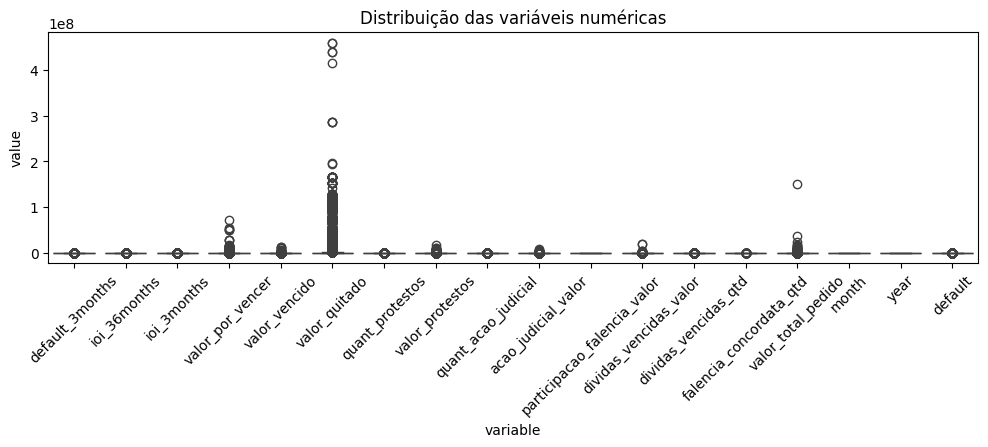

In [21]:
plt.figure(figsize = (12, 3))  # Define largura e altura da figura
df_longo = df.melt(value_vars = numeric_cols) # Converte o dataframe para formato longo para facilitar.
sns.boxplot(x = "variable", y = "value", data = df_longo)
plt.xticks(rotation = 45)
plt.title("Distribuição das variáveis numéricas")
plt.show()

### Histograma

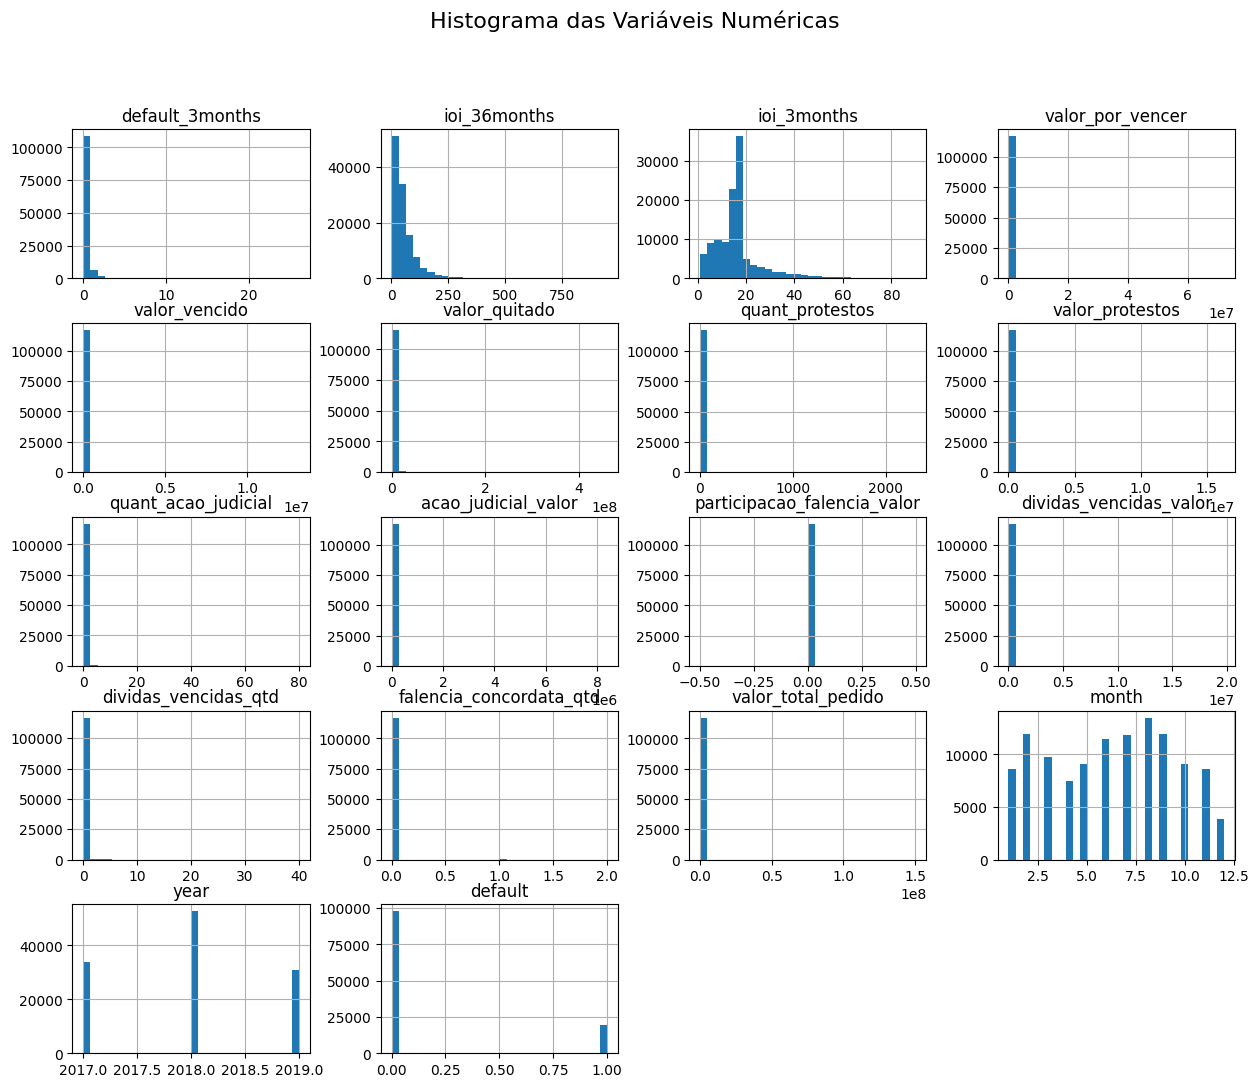

In [23]:
df[numeric_cols].hist(figsize=(15, 12), bins=30)
plt.suptitle("Histograma das Variáveis Numéricas", fontsize=16)
plt.show()


### Análise de Erros ou Características

In [27]:
# Proporção de outliers por variável
outlier_proportion = outliers.sum() / len(df) * 100
print(outlier_proportion[outlier_proportion > 0].sort_values(ascending=False))

default                    16.666240
valor_quitado              14.239424
valor_por_vencer           14.007487
valor_total_pedido         12.939892
valor_vencido              10.594937
ioi_3months                 9.701295
default_3months             7.584013
ioi_36months                6.248668
valor_protestos             4.362470
quant_protestos             3.734022
quant_acao_judicial         0.824572
dividas_vencidas_valor      0.672789
dividas_vencidas_qtd        0.605425
acao_judicial_valor         0.471549
falencia_concordata_qtd     0.046046
dtype: float64


In [28]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtrar somente os outliers
outlier_data = df[numeric_cols][(df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)]

# Estatísticas descritivas dos outliers
print(outlier_data.describe())

       default_3months  ioi_36months   ioi_3months  valor_por_vencer  \
count      8894.000000   7328.000000  11377.000000      1.642700e+04   
mean          1.960985    231.218644     43.175587      4.114063e+05   
std           2.461430    105.815778     13.435311      1.352334e+06   
min           1.000000    144.167148     28.940777      4.931366e+04   
25%           1.000000    164.000000     33.000000      7.364279e+04   
50%           1.000000    193.000000     39.000000      1.178914e+05   
75%           2.000000    256.000000     49.000000      2.841472e+05   
max          26.000000    951.000000     90.000000      7.219759e+07   

       valor_vencido  valor_quitado  quant_protestos  valor_protestos  \
count   1.242500e+04   1.669900e+04      4379.000000     5.116000e+03   
mean    2.316241e+04   6.838345e+06         6.439598     4.701504e+04   
std     2.476860e+05   1.872137e+07        55.057814     4.203768e+05   
min     1.000000e-02   8.014977e+05         1.000000     6.

In [37]:
#verificando 'Valor total (em Reais) de falências apresentadas pelo Serasa' 
df.participacao_falencia_valor.sum()

np.float64(0.0)

- analisar por que participacao_falencia_valor está completamente zerada

##### clientes possivelmente problemáticos

In [49]:
# Definir os limites para clientes problemáticos
corte = 0.75
corte_protestos = df['quant_protestos'].quantile(corte)  # Exemplo: Top 25%
corte_acao_judicial = df['quant_acao_judicial'].quantile(corte)
corte_default_3months = df['default_3months'].quantile(corte)

# Filtrar clientes problemáticos
clientes_problemas = df[
    (df['quant_protestos'] >= corte_protestos) |
    (df['quant_acao_judicial'] >= corte_acao_judicial) |
    (df['default_3months'] >= corte_default_3months)
]

# Exibir uma amostra dos clientes problemáticos
print(clientes_problemas[['quant_protestos', 'quant_acao_judicial', 'default_3months']].head())


   quant_protestos  quant_acao_judicial  default_3months
0                0                    0                0
1                0                    0                1
2                1                    0                0
3                0                    0                0
4                0                    0                0


In [48]:
# Estatísticas descritivas dos clientes problemáticos
stats_problemas = clientes_problemas.describe()
print(stats_problemas)

       default_3months   ioi_36months    ioi_3months  valor_por_vencer  \
count    117273.000000  117273.000000  117273.000000      1.172730e+05   
mean          0.148721      55.582906      17.106291      6.421384e+04   
std           0.853794      60.989240      10.993605      5.252546e+05   
min           0.000000       1.000000       1.000000      0.000000e+00   
25%           0.000000      20.166667      11.121543      5.657400e+02   
50%           0.000000      38.000000      16.000000      4.451740e+03   
75%           0.000000      69.750000      18.248850      2.006296e+04   
max          26.000000     951.000000      90.000000      7.219759e+07   

       valor_vencido  valor_quitado  quant_protestos  valor_protestos  \
count   1.172730e+05   1.172730e+05    117273.000000     1.172730e+05   
mean    2.454043e+03   1.085557e+06         0.240456     2.051017e+03   
std     8.093313e+04   7.444825e+06        10.707825     8.831758e+04   
min     0.000000e+00   0.000000e+00      

#### Valores muito altos

In [50]:
# Definir os thresholds para valores altos
corte_valor_quitado = df['valor_quitado'].quantile(0.95)
corte_valor_vencido = df['valor_vencido'].quantile(0.95)
corte_quant_protestos = df['quant_protestos'].quantile(0.95)
corte_quant_acao_judicial = df['quant_acao_judicial'].quantile(0.95)

# Filtrar os clientes com valores extremamente altos
clientes_extremos = df[
    (df['valor_quitado'] >= corte_valor_quitado) |
    (df['valor_vencido'] >= corte_valor_vencido) |
    (df['quant_protestos'] >= corte_quant_protestos) |
    (df['quant_acao_judicial'] >= corte_quant_acao_judicial)
]

# Exibir uma amostra dos clientes filtrados
print(clientes_extremos[['valor_quitado', 'valor_vencido', 'quant_protestos', 'quant_acao_judicial']].head())


   valor_quitado  valor_vencido  quant_protestos  quant_acao_judicial
0      242100.70            0.0                0                    0
1     4960846.21            0.0                0                    0
2      158631.93            0.0                1                    0
3      669644.16            0.0                0                    0
4        2010.56            0.0                0                    0


In [52]:
# descritiva dos clientes extremos
print(clientes_extremos.describe())

       default_3months   ioi_36months    ioi_3months  valor_por_vencer  \
count    117273.000000  117273.000000  117273.000000      1.172730e+05   
mean          0.148721      55.582906      17.106291      6.421384e+04   
std           0.853794      60.989240      10.993605      5.252546e+05   
min           0.000000       1.000000       1.000000      0.000000e+00   
25%           0.000000      20.166667      11.121543      5.657400e+02   
50%           0.000000      38.000000      16.000000      4.451740e+03   
75%           0.000000      69.750000      18.248850      2.006296e+04   
max          26.000000     951.000000      90.000000      7.219759e+07   

       valor_vencido  valor_quitado  quant_protestos  valor_protestos  \
count   1.172730e+05   1.172730e+05    117273.000000     1.172730e+05   
mean    2.454043e+03   1.085557e+06         0.240456     2.051017e+03   
std     8.093313e+04   7.444825e+06        10.707825     8.831758e+04   
min     0.000000e+00   0.000000e+00      

In [53]:
#Características adicionais dos clientes extremos

# Agrupar por setor de atividade principal
atividade_principal_extremos = clientes_extremos.groupby('atividade_principal').size().sort_values(ascending=False)
print("Distribuição por Atividade Principal:")
print(atividade_principal_extremos)

# Agrupar por tipo de sociedade
tipo_sociedade_extremos = clientes_extremos.groupby('tipo_sociedade').size().sort_values(ascending=False)
print("\nDistribuição por Tipo de Sociedade:")
print(tipo_sociedade_extremos)


Distribuição por Atividade Principal:
atividade_principal
com de equipamentos de informatica              22629
com de telefones e equip p/ comunicacoes         9851
papelaria                                        9075
com de moveis e estofados                        8226
com de eletrodomesticos                          8156
                                                ...  
locacao de roupas e outros art do vestuario         2
revendedora honda                                   2
promocao de eventos                                 2
sindicato de empregados                             2
usinagem, tratamento, revestimento de metais        1
Length: 204, dtype: int64

Distribuição por Tipo de Sociedade:
tipo_sociedade
sociedade empresaria limitada                     60020
empresario (individual)                           27055
empresa individual respons limitada empresaria    19201
empresario-mei(microempreendedor individual)       6886
sociedade anonima fechada                     

### Segmentação de risco

In [ ]:
# DF para armazenar a segmentação de risco
segmentacao_risco = df.groupby(['atividade_principal', 'tipo_sociedade']).agg(
    taxa_inadimplencia=('default', 'mean'),
    total_clientes=('default', 'count'),
)

# Ordenar pela maior taxa de inadimplência
segmentacao_risco = segmentacao_risco.sort_values(by='taxa_inadimplencia', ascending=False)

# Exibir os segmentos com maior inadimplência
print(segmentacao_risco['taxa_inadimplencia'].head(20))

atividade_principal                          tipo_sociedade                                
tv por assinatura                            empresario (individual)                           1.0
servicos tecnicos                            empresario-mei(microempreendedor individual)      1.0
com  de gas liquefeito de petroleo           sociedade empresaria limitada                     1.0
bazar, armarinho e miudezas em geral         sociedade anonima fechada                         1.0
servicos de telecomunicacoes                 empresa individual respons limitada empresaria    1.0
com de artigos ortopedicos                   empresario-mei(microempreendedor individual)      1.0
com de artigos de otica                      empresario-mei(microempreendedor individual)      1.0
servicos de softwares                        empresario-mei(microempreendedor individual)      1.0
com atacad-papeis e embalagens descartaveis  empresario (individual)                           1.0
servicos         

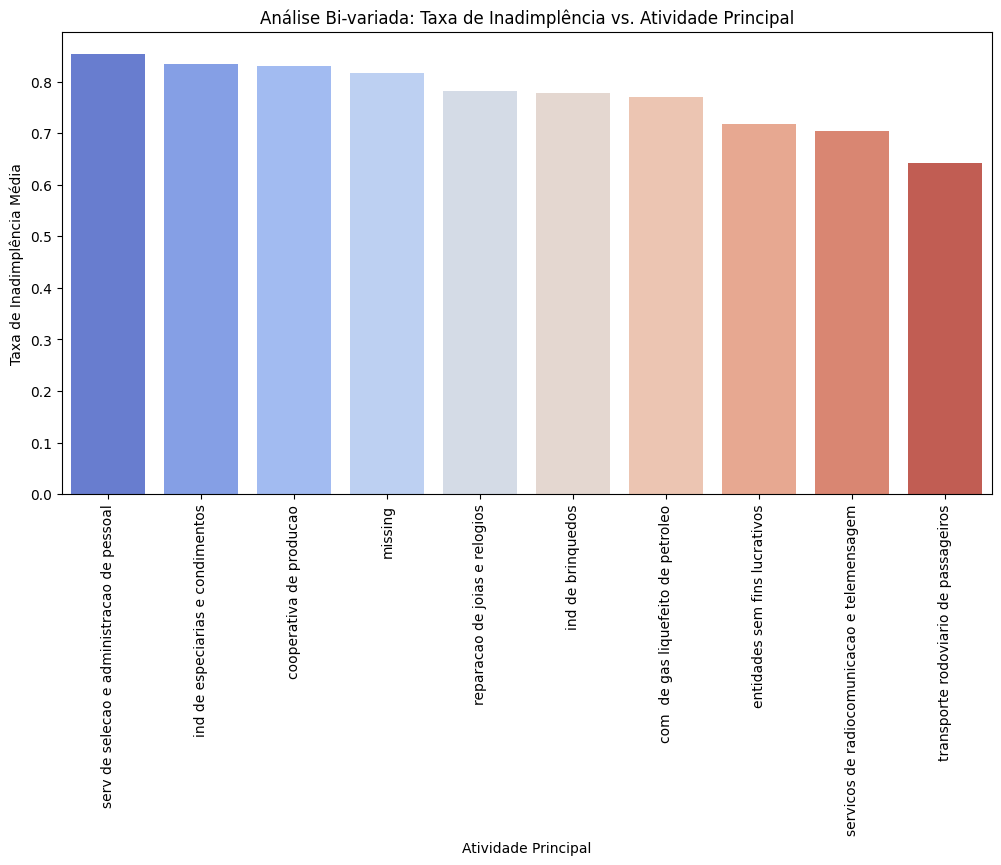

In [62]:
# Função para plotar gráfico de análise bi-variada
def plot_bivariate_analysis(segmentacao_risco):
    plt.figure(figsize=(12, 6))
    top_activities = segmentacao_risco.groupby('atividade_principal')['taxa_inadimplencia'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=top_activities.index, y=top_activities.values, palette='coolwarm')
    plt.xticks(rotation=90)
    plt.xlabel('Atividade Principal')
    plt.ylabel('Taxa de Inadimplência Média')
    plt.title('Análise Bi-variada: Taxa de Inadimplência vs. Atividade Principal')
    plt.show()

# Chamada da função para visualização
top_activities = segmentacao_risco.groupby('atividade_principal')['taxa_inadimplencia'].mean().sort_values(ascending=False).head(10)
plot_bivariate_analysis(segmentacao_risco)

## Outras análises

In [14]:
print("Os anos dos pedidos na base são")
df.year.unique()

Os anos dos pedidos na base são


array([2019, 2018, 2017])

In [15]:
print('Media de inadimplência nos anos: ')
df.groupby('year')[inadimplencia].mean()

Media de inadimplência nos anos: 


year
2017    0.133478
2018    0.189044
2019    0.164740
Name: default, dtype: float64